# [Lab 1](https://colab.research.google.com/github/deeplife4eu/Lecture-materials/blob/main/Week_01/Deep4Life_Lab_1_Introduction_to_pytorch_noSolution.ipynb#scrollTo=tX_iAGqv1yd2): introduction to PyTorch

If the library is not available, install it running <code>pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126</code> through the terminal. Make sure that it is not the cpu version: if you run <code>torch.__version__</code> and it shows something along the lines of 2.x.x+cpu, it is the wrong one.

I had some problems: in synthesis, the GPU was found when running the commands on terminal (<code>python -c "import torch; print(torch.__version__); print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"</code>), but not on Visual Studio Code, where I am running the commands.

I checked the directory of Python with <code>where.exe python</code>. Then added that interpreter on Visual Studio Code with Ctrl + Shift + P, typing Python: Select Interpreter and pasting the path.

In [1]:
import torch
print(f'pytorch version: {torch.__version__}')
num_gpu = torch.cuda.device_count()
print(f'{num_gpu} GPU available')

pytorch version: 2.14.1+cu126
0 GPU available


## Linear regression

Now that we have a GPU available, we are going to try out neural networks starting from a simple task: a linear regression.

As training set, we will generate a dataset from a linear function: the objective is, for our model, to estimate this function starting from the observed points.

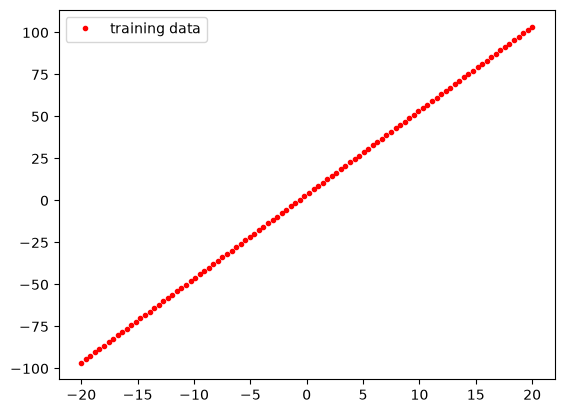

In [3]:
import matplotlib.pyplot as plt
import numpy as np

Xs = np.linspace(-20,20,100) # we start with a hundered X values between -20 and 20

Ys=Xs*5+3.5 # as our Xs are a numpy array, we can perform simple arithmetic on each element of Xs

#Now, we can plot the data we generated

plt.plot(Xs,Ys,"r.",label="training data")
plt.legend()

Now we will set up a very simple neural network with 1 input layer, 1 output layer and 4 hidden layers. Remember that the library PyTorch uses numpy arrays, so we have to define the type of data that goes in them (<code>dtype</code>), and then we need to reshape them into "torch vectors". Other things we have to define, are:
- the Loss Function (in this case MSE, but for a Logistic Regression, for example, we would use Log-Loss);
- the optimizer (in this case SGD with a very small learning rate, but another popular choice is ADAm).

In [4]:
import torch.nn as nn

#we set the parameters of our simple network architecture
N_input=1
N_hidden=4
N_output=1

#create the model based on these parameters
model = nn.Sequential(
    nn.Linear(N_input, N_hidden),
    nn.Linear(N_hidden, N_output),
)

#convert our numpy arrays Xs and Ys into torch vectors we can use in training
inputs = torch.tensor(Xs.reshape((100,1)), dtype=torch.float32)
targets = torch.tensor(Ys.reshape((100,1)), dtype=torch.float32)

# We define the Loss function (Mean Square Error in this case, since this is a 
# linear regression task).
criterion =  torch.nn.MSELoss() 

# Construct the optimizer (Stochastic Gradient Descent in this case)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001) 
# lr is the learning rate


We also set up a training loop. Remember: the number of epochs is, in simple terms, how many times we want the model to cycle through the neurons layers to try and converge to a model with the smallest Loss function possible.

epoch:  0  loss:  3915.4345703125
epoch:  500  loss:  4.893332481384277
epoch:  1000  loss:  0.938977837562561
epoch:  1500  loss:  0.16144391894340515
epoch:  2000  loss:  0.026128992438316345
epoch:  2500  loss:  0.004115757532417774


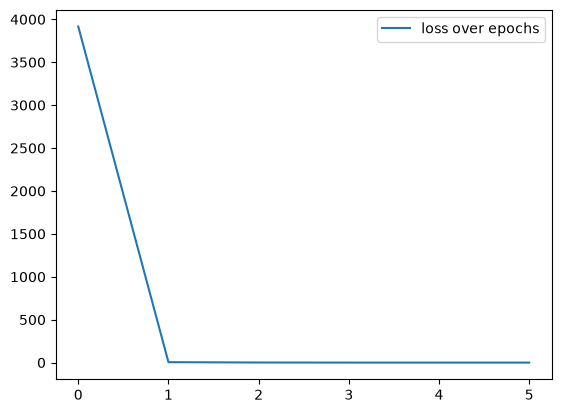

In [5]:
N_epochs=3000
loss_vals=[]
# Gradient Descent
for epoch in range(N_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(inputs)

    # Compute and print loss
    loss = criterion(y_pred, targets)
    # Every 100 epochs, print the loss value, just to keep track
    if epoch % 500 == 0: 
        print('epoch: ', epoch, ' loss: ', loss.item())
        loss_vals.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()

    # perform a backward pass (backpropagation)
    loss.backward()

    # Update the parameters
    optimizer.step()

plt.plot(loss_vals,label="loss over epochs")
plt.legend()

If we do just a tiny little zoom we can get some information on how the model learns: the first steps are important to drastically reduce the Loss error, but the last ones slowly bring the Loss function close to 0. In the tutorial, the zoom was originally (-.5,15), but I changed it to (-.5,2) to better visualize the loss values of my neural network. The fact that I can reach way smaller values of loss than the tutorial is a good sign that my neural network is learning well. 

(-0.1, 2.0)

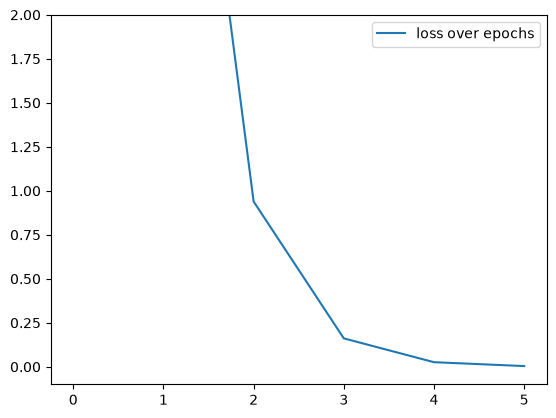

In [8]:
plt.plot(loss_vals,label="loss over epochs")
plt.legend()
plt.ylim(-.1,2) 

Now that we have a model that is ready, we can see how it behaves on test data. We will generate some more few points and see how the model will act.

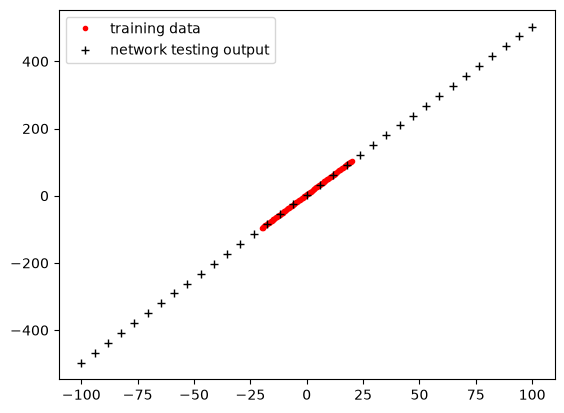

In [9]:
test_Xs= np.linspace(-100,100,35)
test_Ys=test_Xs*5+3.5

with torch.no_grad(): # turning off the autograd of PyTorch
    test_data = torch.tensor(test_Xs.reshape((35,1)), dtype=torch.float32)
    test_output = model(test_data)

#plot the results
plt.plot(Xs,Ys,"r.",label="training data")
plt.plot(test_Xs,test_output,"k+",label="network testing output")
plt.legend()

## Non-linear function f 2 arguments

We are going to do the same exact thing but for a more complicated function: $Y = 5x^2-3x+15$. This time we will use ReLU as activation function, two hidden layers instead of one and also the Adam optimizer to speed up the process.

torch.Size([2500, 2])

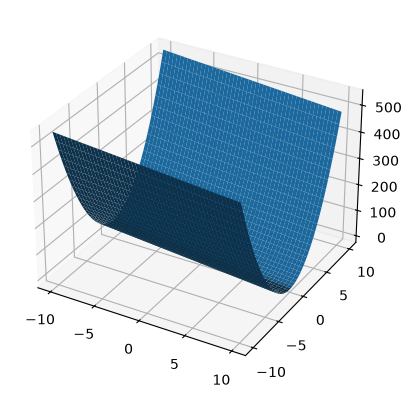

In [14]:
Xs1 = np.linspace(-10,10,50)
Xs2 = np.linspace(-10,10,50)

Xs1,Xs2 = np.meshgrid(Xs1,Xs2) # generate all possible pairs of x1 and x2

Ys = (Xs2**2*5)-(Xs1*3) + 15

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(Xs1, Xs2, Ys, vmin=Ys.min() * 2)

#preparing torch tensors for learning

inputs = torch.tensor(np.concatenate((Xs1.reshape((2500,1)),Xs2.reshape((2500,1))),axis=1), dtype=torch.float32)
targets = torch.tensor(Ys.reshape((2500,1)), dtype=torch.float32)

inputs.shape
#targets.shape

epoch:  0  loss:  59817.46484375
epoch:  10000  loss:  5.332942008972168
epoch:  20000  loss:  3.250971555709839
epoch:  30000  loss:  2.5551400184631348
epoch:  40000  loss:  2.4200150966644287


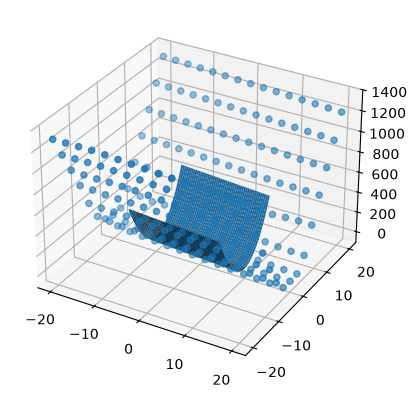

In [ ]:
#model definition
N_input=2
N_hidden=25
N_output=1

#we will now have more hidden layers and more neurons in each of them

model = nn.Sequential(
    nn.Linear(N_input, N_hidden),
    nn.ReLU(),                       # we need non-linear activation functions
    nn.Linear(N_hidden, N_hidden),
    nn.ReLU(),
    nn.Linear(N_hidden, N_hidden),
    nn.ReLU(),
    nn.Linear(N_hidden, N_output),
    nn.ReLU()
)

criterion =  torch.nn.MSELoss()  # Mean Square Error

# Construct the optimizer (Now we use Adam, a bit smarter optimizer)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # lr is the learning rate

N_epochs=50000
loss_vals=[]

# Gradient Descent
for epoch in range(N_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(inputs)

    # Compute and print loss
    loss = criterion(y_pred, targets)
    if epoch % 10000 == 0:                              #we will print fewer loss values
        print('epoch: ', epoch, ' loss: ', loss.item())
        loss_vals.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()

    # perform a backward pass (backpropagation)
    loss.backward()

    # Update the parameters
    optimizer.step()

# Amd now we test it!
test_Xs1 = np.linspace(-20,20,15)
test_Xs2 = np.linspace(-20,20,15)

test_Xs1,test_Xs2 = np.meshgrid(test_Xs1,test_Xs2)

with torch.no_grad():
    test_data = torch.tensor(np.concatenate((test_Xs1.reshape((225,1)),test_Xs2.reshape((225,1))),axis=1), dtype=torch.float32)
    test_output = model(test_data)

test_mesh_output=test_output.reshape((15,15))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(Xs1, Xs2, Ys,label="training data")
ax.scatter(test_Xs1,test_Xs2,test_mesh_output,label="testing data")



## Example 3 - XOR-like function

Let's go more on a realistic setting. The function we will use should be pretty difficult for a simple 1-layer perceptron model.

In [ ]:
# let us start with some random X1,X2 point pairs from 0,2 interval
N_samples=100
train_X1s=np.random.rand(N_samples)*2
train_X2s=np.random.rand(N_samples)*2

def XOR_like(x1,x2):
    if (x1>=1 and x2<=1) or (x2>=1 and x1<=1):
        return 1
    else:
        return 0
train_Ys=np.array([XOR_like(x1,x2) for x1,x2 in zip(train_X1s,train_X2s)])

#prepare input and output data
inputs = torch.tensor(np.concatenate((train_X1s.reshape((N_samples,1)),train_X2s.reshape((N_samples,1))),axis=1), dtype=torch.float32)
targets = torch.tensor(train_Ys.reshape((N_samples,1)), dtype=torch.float32)


##### ONE LAYER PERCEPTRON MODEL
#model definition
N_input=2
N_output=1

#This is the simplest network so far, just a simple perceptron

model = nn.Sequential(
    nn.Linear(N_input, N_output),
    nn.ReLU(),                       # we need non-linear activation functions
    )

criterion =  torch.nn.MSELoss()  # Mean Square Error

# Construct the optimizer (Now we use Adam, a bit smarter optimizer)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # lr is the learning rate

N_epochs=5000
loss_vals=[]

# Gradient Descent
for epoch in range(N_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(inputs)

    # Compute and print loss
    loss = criterion(y_pred, targets)
    if epoch % 1000 == 0:                              #we will print fewer loss values
        print('epoch: ', epoch, ' loss: ', loss.item())
        loss_vals.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()

    # perform a backward pass (backpropagation)
    loss.backward()

    # Update the parameters
    optimizer.step()

###### TEST!

N_samples=100
test_X1s=np.random.rand(N_samples)*2
test_X2s=np.random.rand(N_samples)*2

test_Ys=np.array([XOR_like(x1,x2) for x1,x2 in zip(test_X1s,test_X2s)])

#prepare test input  data
test_inputs = torch.tensor(np.concatenate((test_X1s.reshape((N_samples,1)),test_X2s.reshape((N_samples,1))),axis=1), dtype=torch.float32)

with torch.no_grad():
    test_output = model(test_inputs)



##### MULTIPLE LAYERS PERCEPTRON MODEL
#model definition
N_input_2=2
N_hidden_2=20
N_output_2=1

#This is the simplest network so far, just a simple perceptron

model_2 = nn.Sequential(
    nn.Linear(N_input_2, N_hidden_2),
    nn.ReLU(),                       # we need non-linear activation functions
    nn.Linear(N_hidden_2, N_hidden_2),
    nn.ReLU(),
    nn.Linear(N_hidden_2, N_hidden_2),
    nn.ReLU(),
    nn.Linear(N_hidden_2, N_output_2),
    nn.Sigmoid() # The model was not converging, so I substituted the last step with a Sigmoid
)

criterion =  torch.nn.MSELoss()  # Mean Square Error

# Construct the optimizer (Now we use Adam, a bit smarter optimizer)

optimizer = torch.optim.Adam(model_2.parameters(), lr=0.01) # I make the learnign rate bigger

N_epochs=15000
loss_vals=[]

# Gradient Descent
for epoch in range(N_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred_2 = model_2(inputs)

    # Compute and print loss
    loss = criterion(y_pred_2, targets)
    if epoch % 5000 == 0:                              #we will print fewer loss values
        print('epoch: ', epoch, ' loss: ', loss.item())
        loss_vals.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()

    # perform a backward pass (backpropagation)
    loss.backward()

    # Update the parameters
    optimizer.step()

###### TEST!

N_samples=100
test_X1s_2=np.random.rand(N_samples)*2
test_X2s_2=np.random.rand(N_samples)*2

test_Ys_2=np.array([XOR_like(x1,x2) for x1,x2 in zip(test_X1s_2,test_X2s_2)])

#prepare test input  data
test_inputs_2 = torch.tensor(np.concatenate((test_X1s_2.reshape((N_samples,1)),test_X2s_2.reshape((N_samples,1))),axis=1), dtype=torch.float32)

with torch.no_grad():
    test_output_2 = model_2(test_inputs_2)



epoch:  0  loss:  0.4878891110420227
epoch:  1000  loss:  0.2504483461380005
epoch:  2000  loss:  0.24302078783512115
epoch:  3000  loss:  0.24274803698062897
epoch:  4000  loss:  0.24274736642837524
epoch:  0  loss:  0.25043952465057373
epoch:  5000  loss:  4.938826236866589e-07
epoch:  10000  loss:  2.4141950660805378e-08


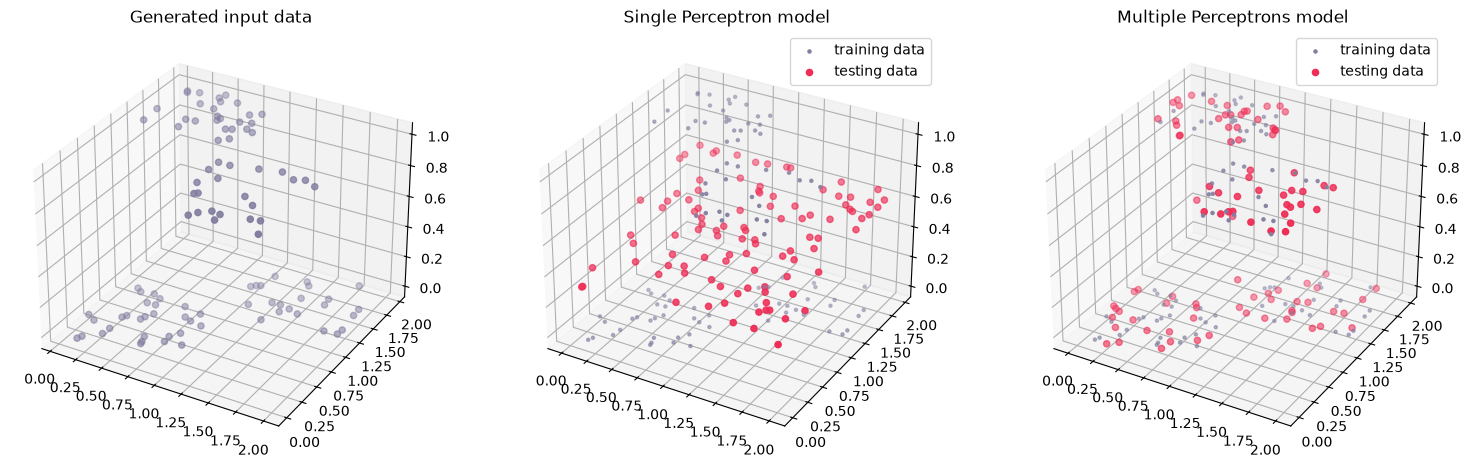

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, subplot_kw={"projection": "3d"})
fig.set_size_inches(18.5, 10.5, forward=True)

ax1.scatter(train_X1s, train_X2s, train_Ys, label="training data", c="#817e9f")
ax1.set_title("Generated input data")

ax2.scatter(train_X1s, train_X2s, train_Ys, label="training data", c = "#817e9f", marker=".")
test_out_flat = test_output.squeeze().numpy()
ax2.scatter(test_X1s, test_X2s, test_out_flat, label="testing data", c = "#ef2d56", marker="o")
ax2.set_title("Single Perceptron model")
ax2.legend(loc="upper right")

test_out_flat_2 = test_output_2.squeeze().numpy()
ax3.scatter(train_X1s, train_X2s, train_Ys, label="training data", c = "#817e9f", marker=".")
ax3.scatter(test_X1s_2, test_X2s_2, test_out_flat_2, label="testing data", c = "#ef2d56", marker="o")
ax3.set_title("Multiple Perceptrons model")
ax3.legend(loc="upper right")

The Lab continues with examples of underfitting and overfitting, but since I am familiar with these concepts I won't continue. There are, though, Homework assignments which I am going to try:

# Assignments for homework

As different groups at different Universities will use different scoring criteria, this might be completely optional for some of you and compulsory for some of you. It might or might not contribute to your grade. **Please consult with your instructors**

Homework assignments:

1.   Please take a look at the [PyTorch beginner tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html). We did not use the dataset and dataloader API, but this should not stop you. Choose one of the examples from today's lecture and extend it so that it uses datasets and dataloaders
2.   One more thing that you might want to consider is re-writing the training loops to use the dataloaders and minibatches as in the [pytorch tutorial](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
